# WaDI Experiments

## Load Data

In [1]:
# Load wadi data
from bdm.Experiments.data_loader import wadi_data

train_df, test_df, signal_variables, control_variables, dict_continuous_variables, dict_discrete_variables = wadi_data()
print(train_df.values.shape, test_df.values.shape)

(241921, 127) (15701, 129)


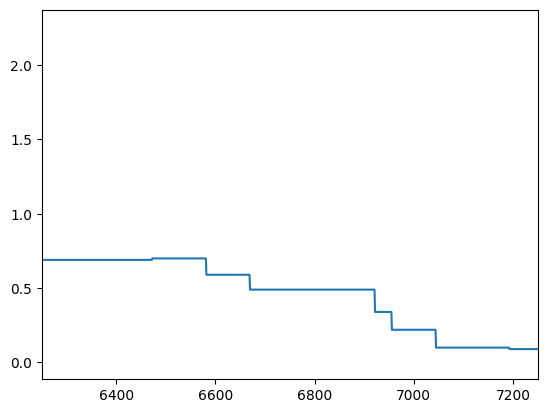

In [2]:
# Prepare data for RS
import numpy as np
import matplotlib.pyplot as plt

x = train_df.values

x -= np.mean(x, axis=0, keepdims=True)
x[:, np.std(x, axis=0) > 0] /= np.std(x, axis=0, keepdims=True)[:, np.std(x, axis=0) > 0]

x = np.nan_to_num(x, nan=0)

# TOTAL_CONS_REQUIRED_FLOW changes at 711
x_esn_fit = x[:1200]
# x_rhy_fit = x[400:900]
x_rhy_fit = x[6600-100-200-100:6600+200]

plt.plot(train_df["TOTAL_CONS_REQUIRED_FLOW"])
plt.xlim([6250, 7250])
plt.show()

# Swat ones
# x_esn_fit = x[:1200]
# x_rhy_fit = x[280:580]

## Find hyperparams

In [3]:
# Find hp

from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for iw in np.linspace(0.1, 0.2, 10): # np.linspace(0.1, 0.5, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=0.5,
        input_weight=iw,
        average_degree_nodes=8,
        num_nodes=768, #512,
        leakage=0,
        # Rhythmic params
        link_strength_change_ratio=0
    )
    
    for sr in tqdm(np.linspace(0.1, 0.2, 10)): # tqdm(np.linspace(0.1, 0.5, 10)):
        for l in np.linspace(0.4, 0.5, 10): # np.linspace(0.25, 0.5, 10):
            network.change_spectral_rad_and_leakage(sr, l)

            network.train(x_esn_fit.T[:, :-200])
            pred = network.predict(x_esn_fit.T[:, -300:], warmup_time=100)
            mse = np.mean(np.square((pred[:, 1:] - x_esn_fit.T[:, -200:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
            if mse > 100_000_000:
                network.lsqrs = not network.lsqrs
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

KeyboardInterrupt: 

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr
New best 0.0005427189 (np.float64(0.25), np.float64(-0.1), np.float64(0.3), np.float64(0.01))


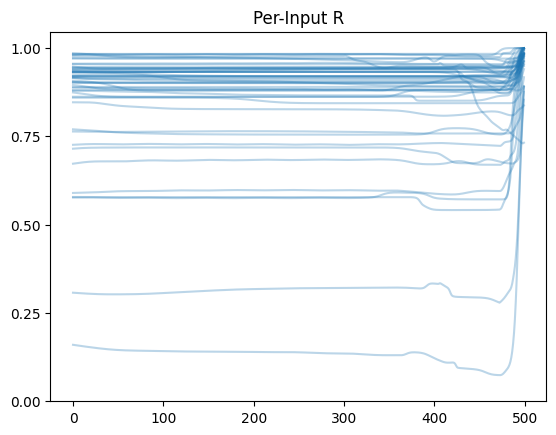

New best 0.0012077087 (np.float64(0.25), np.float64(-0.1), np.float64(0.37777777777777777), np.float64(0.01))


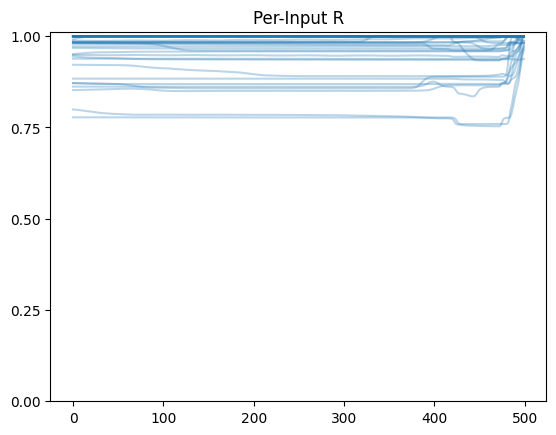

New best 0.0059157645 (np.float64(0.25), np.float64(-0.1), np.float64(0.5333333333333333), np.float64(0.01))


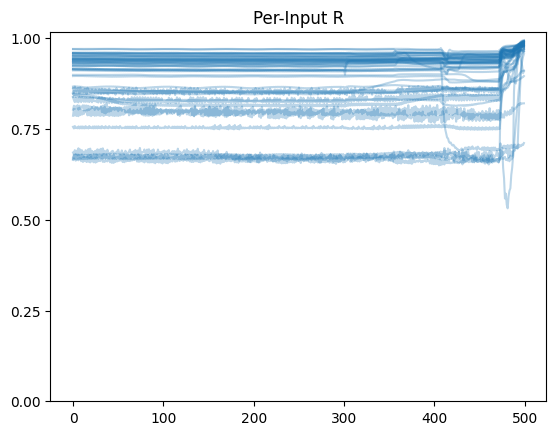

 10%|███████▉                                                                       | 1/10 [27:05<4:03:50, 1625.56s/it]

New best 0.0128770029 (np.float64(0.25), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.01))


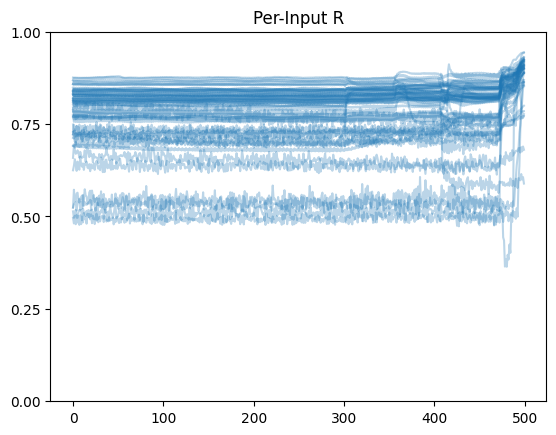

New best 0.0129654963 (np.float64(1.0), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.01))


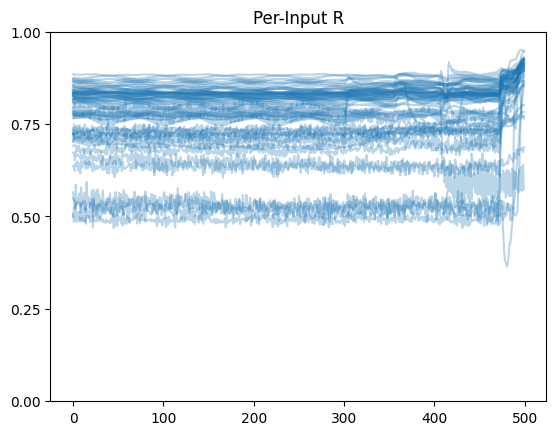

 50%|██████████████████████████████████████▌                                      | 5/10 [2:15:15<2:15:12, 1622.43s/it]

New best 0.0132889235 (np.float64(0.25), np.float64(-0.15555555555555556), np.float64(0.6888888888888889), np.float64(0.01))


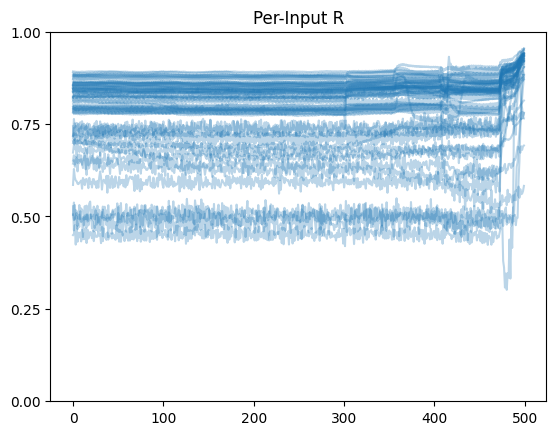

New best 0.0134998380 (np.float64(0.3333333333333333), np.float64(-0.15555555555555556), np.float64(0.6888888888888889), np.float64(0.01))


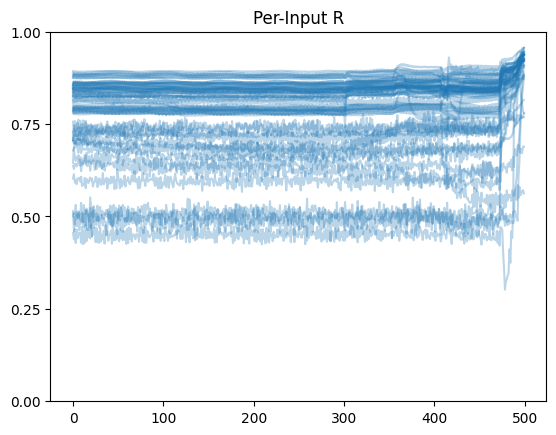

New best 0.0136255848 (np.float64(0.41666666666666663), np.float64(-0.15555555555555556), np.float64(0.6888888888888889), np.float64(0.01))


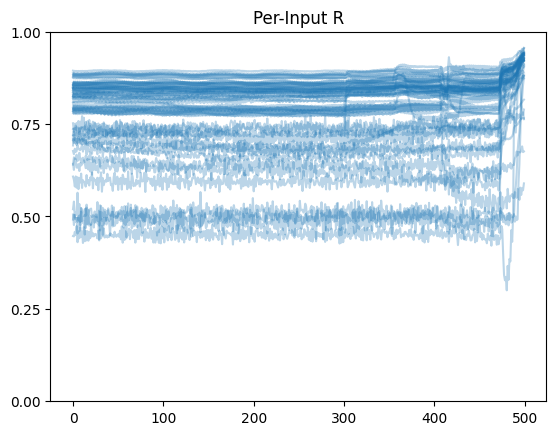

 90%|███████████████████████████████████████████████████████████████████████        | 9/10 [4:03:27<27:02, 1622.79s/it]

New best 0.0153946253 (np.float64(0.25), np.float64(-0.2), np.float64(0.7666666666666666), np.float64(0.01))


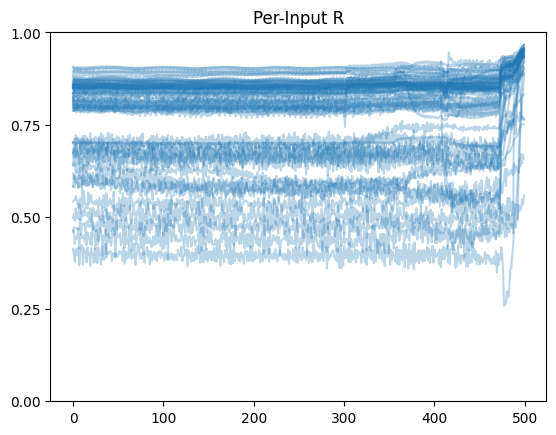

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

...

Switching to lsqr


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


 60%|██████████████████████████████████████████████▏                              | 6/10 [2:34:56<1:43:17, 1549.44s/it]


KeyboardInterrupt: 

In [36]:
import matplotlib.pyplot as plt

best_difference = 0

for o in np.linspace(0.01, 0.4, 10): # np.linspace(0.25, 0.35, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=best_esn_param[0],
        input_weight=best_esn_param[1],
        average_degree_nodes=8,
        num_nodes=768,
        leakage=best_esn_param[2],
        # Rhythmic params
        link_strength_change_ratio=0,
        omega0=o,
        epsilon1=0,
        epsilon2=0,
    )
    
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)[::-1]): #tqdm(np.linspace(-0.15, -0.06, 10)[::-1]):
        for lsr in np.linspace(0.25, 1, 10): # np.linspace(0.8, 1, 10):
            for e2 in np.linspace(0.3, 1.0, 10): # np.linspace(0.5, .7, 10):
                network.epsilon1 = e1
                network.epsilon2 = e2
                network.link_strength_change_ratio = lsr
                network.reset_initial_states()
                network.reset_history()
                
                network.train(x_rhy_fit.T, warmup_time=100)
                r = network.get_global_parameters()[0]
    
                # diff = np.std(r.T[:200])/np.std(r.T[-200:])
                diff = np.abs(np.mean(r.T[-400:-200]) - np.mean(r.T[-200:])) #/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[-400:-200]) > 0.5: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [4]:
# Presaved params

best_esn_param = (0.14, 0.4, 0.3) # best_esn_param = (0.21, 0.41, 0.39) # best_esn_param = (0.14, 0.41, 0.33)
best_param_rhy = (0.96, -0.11, 0.26, 0.1) # best_param_rhy = (1.0, -0.19, 0.46, 0.05) # best_param_rhy = (0.58, -0.12, 0.30, 0.18)

## Run data through RS

In [6]:
# Run network on train_df
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
train_r = network.get_input_parameters()[0].T
assert np.max(train_r, axis=0, keepdims=True).shape[1] == x.shape[1]
train_r = (train_r - np.min(train_r, axis=0, keepdims=True))/(np.max(train_r, axis=0, keepdims=True) - np.min(train_r, axis=0, keepdims=True))
train_r = train_r.astype(float)

100%|████████████████████████████████████████████████████████████████████████| 241921/241921 [1:50:03<00:00, 36.64it/s]


In [41]:
# Load test_df
x = test_df.values[:, 1:-1].astype(float)

x -= np.mean(x, axis=0, keepdims=True)
x[:, np.std(x, axis=0) > 0] /= np.std(x, axis=0, keepdims=True)[:, np.std(x, axis=0) > 0]

x = np.nan_to_num(x, nan=0)
x.shape

(15701, 127)

In [8]:
# Run network on test_df
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
test_r = network.get_input_parameters()[0].T
assert np.max(test_r, axis=0, keepdims=True).shape[1] == x.shape[1]
test_r = (test_r - np.min(test_r, axis=0, keepdims=True))/(np.max(test_r, axis=0, keepdims=True) - np.min(test_r, axis=0, keepdims=True))
test_r = test_r.astype(float)

100%|████████████████████████████████████████████████████████████████████████████| 15701/15701 [07:30<00:00, 34.89it/s]


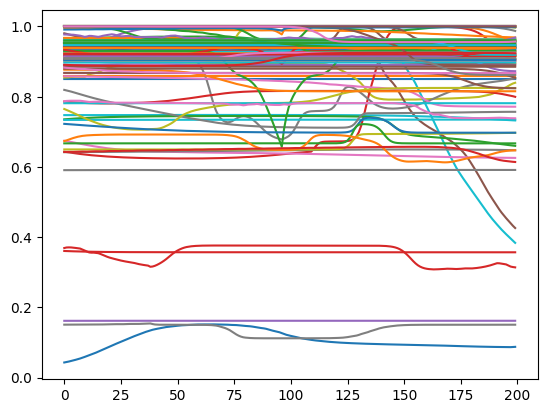

In [9]:
# Plot example from test
import matplotlib.pyplot as plt

plt.plot(test_r[919:1119])
plt.show()

## BDM

In [10]:
# Train bdm
# import keras
# keras.config.set_backend("tensorflow")

import bdm.Algorithm.BDM as new_bdm
import pandas as pd

new_train_df = pd.DataFrame(train_r, columns=train_df.columns).astype(float)

xl = 8
ul = xl * 2
batch_size = 256
bdm = new_bdm.BDM(x_length=xl, u_length=ul)
epochs = 250

x_prev, x_curr, x_next, u_curr, _ = bdm.prepare_data(
    new_train_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label=None, normalization=None, freq=1
)

x_dim = int(x_curr.shape[1]/xl)
index = np.arange(len(x_prev))
train_pos = index[:(len(x_prev) * 3 // 4)]
val_pos = index[(len(x_prev) * 3 // 4):]

x_train_bdm = [x_prev[train_pos, :], x_curr[train_pos, :], x_next[train_pos, :], u_curr[train_pos, :]]
x_val_bdm = [x_prev[val_pos, :], x_curr[val_pos, :], x_next[val_pos, :], u_curr[val_pos, :]]

bdm.train(x_train_bdm, s_dim=4, s_activation='tanh', batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=2)

Epoch 1/250
638/638 - 38s - 60ms/step - functional_1_loss: 0.1469 - functional_loss: 0.1782 - loss: 0.4613 - subtract_1_loss: 0.0155 - subtract_loss: 0.0152 - val_functional_1_loss: 0.0271 - val_functional_loss: 0.0443 - val_loss: 0.0867 - val_subtract_1_loss: 0.0042 - val_subtract_loss: 0.0037
Epoch 2/250
638/638 - 17s - 27ms/step - functional_1_loss: 0.0256 - functional_loss: 0.0182 - loss: 0.0791 - subtract_1_loss: 0.0018 - subtract_loss: 0.0018 - val_functional_1_loss: 0.0239 - val_functional_loss: 0.0082 - val_loss: 0.0729 - val_subtract_1_loss: 6.6803e-04 - val_subtract_loss: 7.1576e-04
Epoch 3/250
638/638 - 18s - 28ms/step - functional_1_loss: 0.0241 - functional_loss: 0.0080 - loss: 0.0734 - subtract_1_loss: 7.9252e-04 - subtract_loss: 7.8479e-04 - val_functional_1_loss: 0.0230 - val_functional_loss: 0.0067 - val_loss: 0.0700 - val_subtract_1_loss: 8.3211e-04 - val_subtract_loss: 9.2428e-04
Epoch 4/250
638/638 - 18s - 28ms/step - functional_1_loss: 0.0228 - functional_loss: 0.0

In [12]:
# Test bdm
from bdm.Algorithm.utils import f_search
from sklearn import metrics

bdm.estimate_system(x_val_bdm)

new_test_df = pd.DataFrame(
    np.concatenate([test_r, test_df.values[:, -1:]], axis=1),
    columns=list(test_df.columns[1:-1]) + [test_df.columns[-1]]
).astype(float)

_, x_curr, _, u_curr, labels = bdm.prepare_data(
    new_test_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label='label', normalization=None, freq=xl
)

test_x_bdm = x_curr; test_u_bdm = u_curr

z_scores_bdm = bdm.test(test_x_bdm, test_u_bdm)
z_scores_bdm = np.nan_to_num(z_scores_bdm)
t, _ = f_search(z_scores_bdm, labels[1:])

print('BDM')
print('best-f1', t[0]) # Before removing > 0.7, this was 0.75
print('precision', t[1])
print('recall', t[2])
print('accuracy', (t[3] + t[4]) / (t[3] + t[4] + t[5] + t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print('AUC:', metrics.roc_auc_score(labels[1:], z_scores_bdm))

del x_train_bdm, x_val_bdm, x_prev, x_curr, x_next, u_curr, bdm

1890/1890 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
BDM
best-f1 0.22573847167498795
precision 0.1583333289351853
recall 0.3931034211652813
accuracy 0.8004083716181726
TP 57.0
TN 1511.0
FP 303.0
FN 88.0
AUC: 0.5719309584458048


## NSIBF

In [13]:
# Setup NSIBF
import os, sys
sys.path.append(os.path.abspath("NSIBF"))

import NSIBF.framework.models as models
from NSIBF.framework.HPOptimizer.Hyperparameter import UniformIntegerHyperparameter,ConstHyperparameter, UniformFloatHyperparameter
from NSIBF.framework.HPOptimizer import HPOptimizers
from NSIBF.framework.preprocessing import normalize_and_encode_signals
from NSIBF.framework.preprocessing.signals import SignalSource, ContinousSignal
from NSIBF.framework.utils.metrics import bf_search
from NSIBF.framework.utils import negative_sampler

signals = []
for c in list(test_df.columns[1:-2]):
    signals.append(ContinousSignal(c, SignalSource.sensor, isInput=True, isOutput=True, min_value=0, max_value=1))

seqL = 12
kf = models.NSIBF(signals, window_length=seqL, input_range=seqL*3)

pos = len(new_train_df)*3//4
nsibf_val_df = new_train_df.loc[pos:,:].astype(float)
nsibf_val_df = nsibf_val_df.reset_index(drop=True)

nsibf_train_df = new_train_df.loc[:pos,:].astype(float)
nsibf_train_df = new_train_df.reset_index(drop=True)

nsibf_train_df = normalize_and_encode_signals(nsibf_train_df, signals, scaler='min_max')
train_x,train_u,train_y,_ = kf.extract_data(nsibf_train_df)
x_train = [train_x,train_u]
y_train = [train_x,train_y]

x,u,y = [],[],[]
for i in range(20):
    r = 0.05*i
    negative_df = negative_sampler.apply_negative_samples(nsibf_val_df, signals, sample_ratio=r, sample_delta=0.05)
    negative_df = normalize_and_encode_signals(negative_df,signals,scaler='min_max')
    neg_x,neg_u,_,neg_labels = kf.extract_data(negative_df,purpose='AD',freq=seqL,label='class_label')
    neg_labels = neg_labels.sum(axis=1)
    neg_labels[neg_labels<seqL]=0
    neg_labels[neg_labels==seqL]=1
    x.append(neg_x)
    u.append(neg_u)
    y.append(neg_labels)
x = np.concatenate(x)
u = np.concatenate(u)
y = np.concatenate(y)
print(list(y).count(1),len(y))
x_neg = [x,u]
y_neg = y

11151 100760


In [14]:
# Train NSIBF

hp_list = []
hp_list.append(UniformIntegerHyperparameter('z_dim',1,75)) 
hp_list.append(UniformIntegerHyperparameter('hnet_hidden_layers',1,3))  
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_dim',32,256))
hp_list.append(UniformIntegerHyperparameter('uencoding_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('uencoding_dim',32,256))
hp_list.append(UniformFloatHyperparameter('l2',0,0.05))
hp_list.append(ConstHyperparameter('epochs',25))
hp_list.append(ConstHyperparameter('save_best_only',True))
hp_list.append(ConstHyperparameter('validation_split',0.1))
hp_list.append(ConstHyperparameter('batch_size',256*8))
hp_list.append(ConstHyperparameter('verbose',2))

optor = HPOptimizers.RandomizedGS(kf, hp_list,x_train, y_train,x_neg,y_neg)
kf,optHPCfg,bestScore = optor.run(n_searches=10,verbose=1)


Epoch 1/25
107/107 - 187s - 2s/step - h_net_loss: 0.1280 - loss: 375.5357 - smoothing_loss: 0.0914 - val_h_net_loss: 0.0337 - val_loss: 0.8513 - val_smoothing_loss: 1.9861e-04
Epoch 2/25
107/107 - 175s - 2s/step - h_net_loss: 0.0244 - loss: 0.5041 - smoothing_loss: 1.1675e-04 - val_h_net_loss: 0.0341 - val_loss: 0.5085 - val_smoothing_loss: 1.1742e-04
Epoch 3/25
107/107 - 172s - 2s/step - h_net_loss: 0.0244 - loss: 0.3133 - smoothing_loss: 7.0752e-05 - val_h_net_loss: 0.0342 - val_loss: 0.3722 - val_smoothing_loss: 8.4058e-05
Epoch 4/25
107/107 - 177s - 2s/step - h_net_loss: 0.0245 - loss: 0.2192 - smoothing_loss: 4.7907e-05 - val_h_net_loss: 0.0340 - val_loss: 0.2878 - val_smoothing_loss: 6.3440e-05
Epoch 5/25
107/107 - 171s - 2s/step - h_net_loss: 0.0244 - loss: 0.1694 - smoothing_loss: 3.5888e-05 - val_h_net_loss: 0.0343 - val_loss: 0.2461 - val_smoothing_loss: 5.3195e-05
Epoch 6/25
107/107 - 171s - 2s/step - h_net_loss: 0.0244 - loss: 0.1391 - smoothing_loss: 2.8559e-05 - val_h_ne

score: 0.5587228392735856 {'z_dim': 74, 'hnet_hidden_layers': 2, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 215, 'uencoding_layers': 2, 'uencoding_dim': 236, 'l2': 0.027284398271910554, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
107/107 - 45s - 424ms/step - h_net_loss: 0.2287 - loss: 283.7337 - smoothing_loss: 0.3986 - val_h_net_loss: 0.0330 - val_loss: 213.4588 - val_smoothing_loss: 0.3001
Epoch 2/25
107/107 - 34s - 321ms/step - h_net_loss: 0.0247 - loss: 81.2955 - smoothing_loss: 0.1139 - val_h_net_loss: 0.0341 - val_loss: 0.0437 - val_smoothing_loss: 1.7059e-05
Epoch 3/25
107/107 - 35s - 328ms/step - h_net_loss: 0.0244 - loss: 0.0256 - smoothing_loss: 4.8755e-06 - val_h_net_loss: 0.0339 - val_loss: 0.0321 - val_smoothing_loss: 1.9915e-06
Epoch 4/25
107/107 - 35s - 327ms/step - h_net_loss: 0.0244 - loss: 0.0221 - smoothing_loss: 2.4940e-07 - val_h_net_loss: 0.0339 - val_loss: 0.0316 - val_smoothing_loss: 1.3116e-06
Epo

score: 0.5699864911453526 {'z_dim': 67, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 214, 'uencoding_layers': 2, 'uencoding_dim': 56, 'l2': 0.005160896620963529, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
107/107 - 55s - 510ms/step - h_net_loss: 0.1218 - loss: 5.7744 - smoothing_loss: 0.1116 - val_h_net_loss: 0.0339 - val_loss: 0.0422 - val_smoothing_loss: 2.6055e-04
Epoch 2/25
107/107 - 44s - 415ms/step - h_net_loss: 0.0242 - loss: 0.0255 - smoothing_loss: 1.0554e-04 - val_h_net_loss: 0.0336 - val_loss: 0.0354 - val_smoothing_loss: 1.5064e-04
Epoch 3/25
107/107 - 44s - 415ms/step - h_net_loss: 0.0234 - loss: 0.0223 - smoothing_loss: 6.4392e-05 - val_h_net_loss: 0.0303 - val_loss: 0.0308 - val_smoothing_loss: 1.0993e-04
Epoch 4/25
107/107 - 45s - 418ms/step - h_net_loss: 0.0192 - loss: 0.0191 - smoothing_loss: 4.8345e-05 - val_h_net_loss: 0.0253 - val_loss: 0.0268 - val_smoothing_loss: 8.6038e-05
E

score: 0.5877824858339163 {'z_dim': 30, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 212, 'uencoding_layers': 2, 'uencoding_dim': 253, 'l2': 0.005791880292841056, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
107/107 - 147s - 1s/step - h_net_loss: 0.1058 - loss: 244.2579 - smoothing_loss: 0.8763 - val_h_net_loss: 0.0326 - val_loss: 228.4800 - val_smoothing_loss: 0.8513
Epoch 2/25
107/107 - 132s - 1s/step - h_net_loss: 0.0298 - loss: 69.6104 - smoothing_loss: 0.2482 - val_h_net_loss: 0.0340 - val_loss: 0.0332 - val_smoothing_loss: 1.0413e-05
Epoch 3/25
107/107 - 132s - 1s/step - h_net_loss: 0.0244 - loss: 0.0222 - smoothing_loss: 1.8481e-06 - val_h_net_loss: 0.0337 - val_loss: 0.0306 - val_smoothing_loss: 2.4373e-06
Epoch 4/25
107/107 - 132s - 1s/step - h_net_loss: 0.0243 - loss: 0.0218 - smoothing_loss: 8.6341e-07 - val_h_net_loss: 0.0341 - val_loss: 0.0307 - val_smoothing_loss: 2.2944e-06
Epoch 5/25


In [15]:
# Test NSIBF

nsibf_val_df = normalize_and_encode_signals(nsibf_val_df, signals, scaler='min_max') 
val_x,val_u,val_y,_ = kf.extract_data(nsibf_val_df)

nsibf_test_df = normalize_and_encode_signals(new_test_df,signals,scaler='min_max')
test_x,test_u,_,labels = kf.extract_data(nsibf_test_df, purpose='AD', freq=seqL,label='label')
labels = labels.sum(axis=1)
labels[labels>0]=1

kf.estimate_noise(val_x,val_u,val_y)
 
z_scores = kf.score_samples(test_x, test_u,reset_hidden_states=True)
# np.savetxt('../results/SWAT/NSIBF_scores',z_scores)
# z_scores = np.loadtxt('../results/SWAT/NSIBF_scores')
recon_scores,pred_scores = kf.score_samples_via_residual_error(test_x,test_u)
print()
   
z_scores = np.nan_to_num(z_scores)
t, th = bf_search(z_scores, labels[1:],start=0,end=np.percentile(z_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(recon_scores[1:], labels[1:],start=0,end=np.percentile(recon_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-RECON')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(pred_scores, labels[1:],start=0,end=np.percentile(pred_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-PRED')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()

del nsibf_test_df, nsibf_train_df, nsibf_val_df, train_x, train_u, train_y, val_x, val_u, val_y, kf, HPOptimizers

1889/1889 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
3 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
6 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
8 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
9 / 1306
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
10 / 1306
2/2 ━━━━━━━━━

## Driftbench

In [42]:
# Test using driftbench
from drift_helpers import added_detectors 
from drift_helpers import added_metrics

from driftbench.drift_detection.detectors import (
    RandomGuessDetector,
    RollingMeanDifferenceDetector,
    RollingMeanStandardDeviationDetector,
    AggregateFeatureAlgorithm,
    SlidingKSWINDetector,
    ClusterDetector,
    AutoencoderDetector,
    MMDDetector,
)
from driftbench.drift_detection.metrics import (
    TemporalAUC,
    SoftTAUC,
    AUC,
)

from river.drift import ADWIN, KSWIN, PageHinkley

detectors = [
    # Detectors from driftbench
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=50,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    MMDDetector(window_size=20, stat_size=20, offset=10),
    MMDDetector(window_size=40, stat_size=40, offset=10),
    RollingMeanDifferenceDetector(window_size=20),
    RollingMeanDifferenceDetector(window_size=40),
    RollingMeanStandardDeviationDetector(window_size=20),
    ClusterDetector(n_centers=10, method="kmeans"),
    ClusterDetector(n_centers=10, method="gaussian mixture"),
    ClusterDetector(n_centers=5, method="kmeans"),
    ClusterDetector(n_centers=5, method="gaussian mixture")
]

f1_score = added_metrics.F1_Score()
metrics = [
    f1_score,
    added_metrics.Precision(f1_metric_obj=f1_score),
    added_metrics.Recall(f1_metric_obj=f1_score),
    added_metrics.Delay(f1_metric_obj=f1_score),
    # TemporalAUC(rule='step'),
    # TemporalAUC(rule='trapez'),
    # SoftTAUC(rule='step'),
    # AUC(),
]

output = []

Y = test_df["label"].values

for detector in tqdm(detectors):
    prediction = detector.predict(x)
    r_prediction = detector.predict(test_r)
    print("done predictions")

    try:
        output.append({
            "detector": detector.name,
            "params": detector.get_hparams(),
            "generic_metrics": {
                metric.name: metric(prediction, Y) for metric in metrics
            },
            "r_metrics": {
                metric.name: metric(r_prediction, Y) for metric in metrics
            }
        })
    except ValueError:
        print(detector.name)

  8%|██████▎                                                                           | 1/13 [01:48<21:45, 108.78s/it]

done predictions


 15%|████████████▌                                                                     | 2/13 [07:29<44:54, 244.93s/it]

done predictions


 23%|██████████████████▉                                                               | 3/13 [08:30<26:50, 161.01s/it]

...

 85%|█████████████████████████████████████████████████████████████████████▍            | 11/13 [13:58<01:35, 47.97s/it]

done predictions


 92%|███████████████████████████████████████████████████████████████████████████▋      | 12/13 [14:00<00:34, 34.03s/it]

done predictions


100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [14:23<00:00, 66.41s/it]


In [43]:
# Separate f1 scores by detector and whether using RS
separated_output = {}
for result in output:
    params = ",".join("%s:%s" % (k, v) for k, v in result["params"].items())
    separated_output[result["detector"] + "," + params] = separated_output.get(result["detector"] + "," + params, {
        "generic": [],
        "rs": []
    })

    separated_output[result["detector"] + "," + params]["generic"].append(result["generic_metrics"])
    separated_output[result["detector"] + "," + params]["rs"].append(result["r_metrics"])

print(separated_output[result["detector"] + "," + params]["rs"][0].keys())
for k, v in separated_output.items():
    print(k, np.nanmean([i["Precision"] for i in v["generic"]]), np.nanmean([i["Precision"] for i in v["rs"]]))
    print(k, np.nanmean([i["Recall"] for i in v["generic"]]), np.nanmean([i["Recall"] for i in v["rs"]]))
    print(k, np.nanmean([i["F1_Score"] for i in v["generic"]]), np.nanmean([i["F1_Score"] for i in v["rs"]]))

dict_keys(['F1_Score', 'Precision', 'Recall', 'Delay'])
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:50,hidden_layers:[80, 50, 20, 10, 2] 0.0825242718446602 0.07159747766684182
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:50,hidden_layers:[80, 50, 20, 10, 2] 0.7178796046720575 0.9793351302785265
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:50,hidden_layers:[80, 50, 20, 10, 2] 0.14803149606299215 0.13343943196425292
AutoencoderDetector,activation:tanh,lr:0.0001,optim:adam,num_epochs:100,hidden_layers:[80, 50, 20, 10, 2] 0.08743664011585807 0.07143783223129781
AutoencoderDetector,activation:tanh,lr:0.0001,optim:adam,num_epochs:100,hidden_layers:[80, 50, 20, 10, 2] 0.4339622641509434 0.9901168014375562
AutoencoderDetector,activation:tanh,lr:0.0001,optim:adam,num_epochs:100,hidden_layers:[80, 50, 20, 10, 2] 0.14554768720807593 0.13326077755607957
AutoencoderDetector,activation:tanh,lr:0.0001,optim:adam,num_epochs:10,hidden_l

In [32]:
del HPOptimizers